In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/test_solution_01.csv
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_4_684.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_3_835.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_0_340.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_2_138.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_3_570.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_1_210.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_2_792.jpg
/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final/img_1_581.jpg
/kaggle/inpu

In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
def find_dir(possible_names, search_root='/kaggle/input'):
    if isinstance(possible_names, str):
        possible_names = [possible_names]
    for dirpath, dirnames, _ in os.walk(search_root):
        for name in possible_names:
            if name in dirnames:
                return os.path.join(dirpath, name)
    return None

train_dir = find_dir(['train', 'training'])
test_dir  = find_dir(['test', 'testing', 'kaggle_test_final'])

print("Train:", train_dir)
print("Test: ", test_dir)

Train: /kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train
Test:  /kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final


In [7]:
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
AUTOTUNE   = tf.data.AUTOTUNE

# Generic class distribution
class_names = sorted(os.listdir(train_dir))
class_names = [c for c in class_names if os.path.isdir(os.path.join(train_dir, c))]
NUM_CLASSES = len(class_names)
total = 0
class_counts = {}

for cls in class_names:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    class_counts[cls] = count
    total += count

print(f"Classes : {class_names}")
print(f"Total   : {total}")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} ({count/total*100:.1f}%)")

Classes : ['chihuahua', 'muffin']
Total   : 4733
  chihuahua: 2559 (54.1%)
  muffin: 2174 (45.9%)


In [8]:
# tf.data pipeline
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

# shuffle=False — critical for confusion matrix label alignment
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
print("Classes:", class_names)

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 4733 files belonging to 2 classes.
Using 3787 files for training.


I0000 00:00:1776616036.883194      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776616036.889431      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4733 files belonging to 2 classes.
Using 946 files for validation.
Classes: ['chihuahua', 'muffin']


In [9]:
# Augmentation layer — only applied during training inside the model
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name="augmentation")

In [10]:
# ════════════════════════════════════════════
# OPTION A — EfficientNetB0  ✅ active
# ════════════════════════════════════════════
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
MODEL_NAME = "efficientnet"
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

# ════════════════════════════════════════════
# OPTION B — MobileNetV2
# ════════════════════════════════════════════
# from tensorflow.keras.applications import MobileNetV2
# from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# MODEL_NAME = "mobilenet"
# base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
# base_model.trainable = False

# ════════════════════════════════════════════
# OPTION C — ResNet50V2
# ════════════════════════════════════════════
# from tensorflow.keras.applications import ResNet50V2
# from tensorflow.keras.applications.resnet_v2 import preprocess_input
# MODEL_NAME = "resnet"
# base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
# base_model.trainable = False

# ════════════════════════════════════════════
# OPTION D — VGG16
# ════════════════════════════════════════════
# from tensorflow.keras.applications import VGG16
# from tensorflow.keras.applications.vgg16 import preprocess_input
# MODEL_NAME = "vgg16"
# base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
# base_model.trainable = False

print(f"Using: {MODEL_NAME}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Using: efficientnet


In [11]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)       # augmentation only active during training
x = preprocess_input(x)             # backbone-specific normalisation
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs, name=MODEL_NAME)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "efficientnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,415,652 (16.84 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [12]:
cb_list = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=3, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f"{MODEL_NAME}_best.keras",
        monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

# Phase 1 — frozen backbone
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cb_list,
)

Epoch 1/10


E0000 00:00:1776616051.829038      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnet_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1776616055.223692     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9321 - loss: 0.1754
Epoch 1: val_accuracy improved from -inf to 0.99577, saving model to efficientnet_best.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 42s 220ms/step - accuracy: 0.9323 - loss: 0.1748 - val_accuracy: 0.9958 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 2/10
118/119 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9863 - loss: 0.0507
Epoch 2: val_accuracy improved from 0.99577 to 0.99683, saving model to efficientnet_best.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.9863 - loss: 0.0506 - val_accuracy: 0.9968 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 3/10
118/119 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9910 - loss: 0.0274
Epoch 3: val_accuracy improved from 0.99683 to 0.99789, saving model to efficientnet_best.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.9910 - loss: 0.0275 - val_accuracy: 0.9979 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 4/10
118/119 ━━━━━━━━━━━━━━━

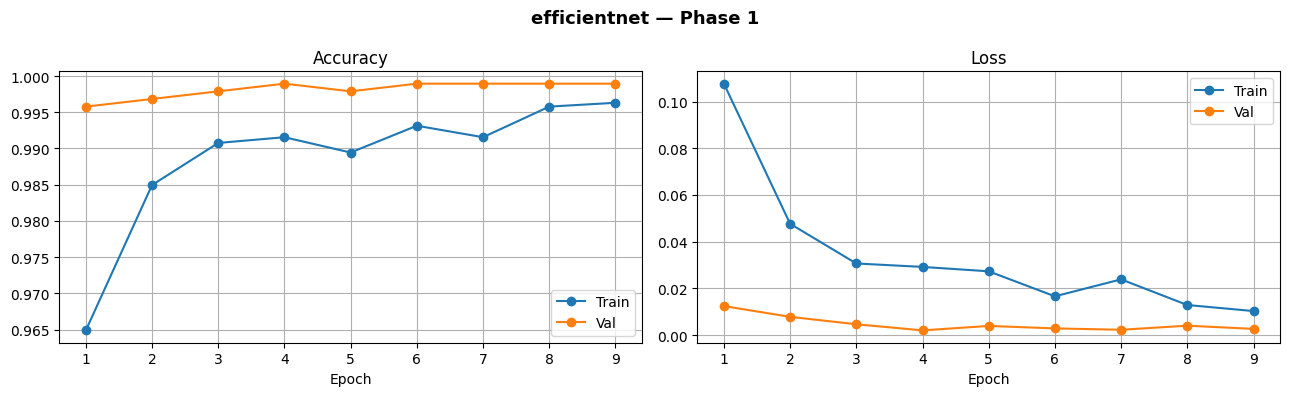

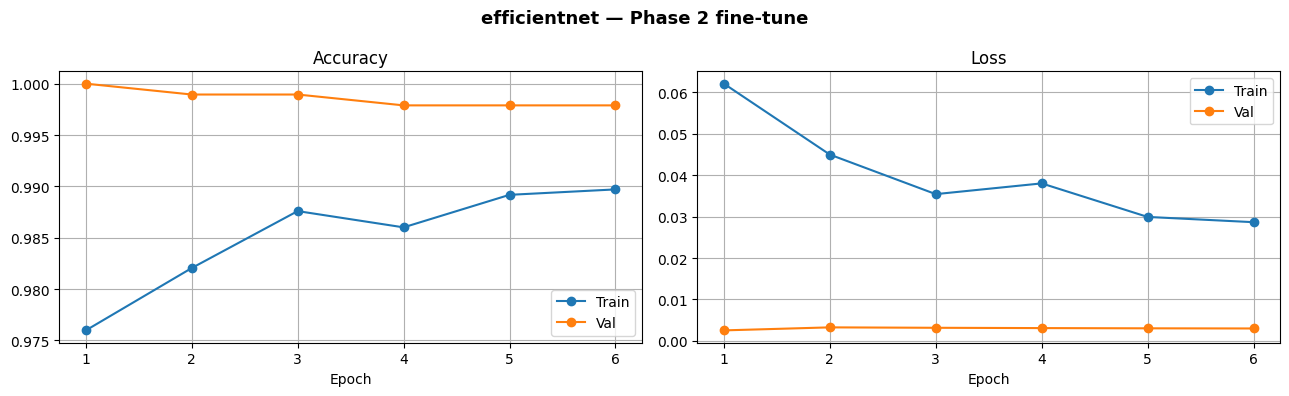

Phase 1 best val acc: 0.9989429116249084
Phase 2 best val acc: 1.0


In [14]:
def plot_history(hist, title=""):
    acc   = hist.history['accuracy']
    vacc  = hist.history['val_accuracy']
    loss  = hist.history['loss']
    vloss = hist.history['val_loss']
    ep    = range(1, len(acc) + 1)

    plt.figure(figsize=(13, 4))
    plt.suptitle(title, fontsize=13, fontweight='bold')

    plt.subplot(1, 2, 1)
    plt.plot(ep, acc,  marker='o', label='Train')
    plt.plot(ep, vacc, marker='o', label='Val')
    plt.title('Accuracy'); plt.xlabel('Epoch')
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(ep, loss,  marker='o', label='Train')
    plt.plot(ep, vloss, marker='o', label='Val')
    plt.title('Loss'); plt.xlabel('Epoch')
    plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history,    f"{MODEL_NAME} — Phase 1")


print("Phase 1 best val acc:", max(history.history['val_accuracy']))


In [15]:
# True labels — extracted from val_ds directly (shuffle=False keeps order)
true_labels = np.concatenate([y.numpy() for _, y in val_ds])

# Predictions
preds       = model.predict(val_ds, verbose=1)
pred_labels = (preds > 0.5).astype(int).flatten()

print(f"Samples — true: {len(true_labels)}, predicted: {len(pred_labels)}")
print("Class order:", class_names)   # index 0 = class_names[0], index 1 = class_names[1]

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step
Samples — true: 946, predicted: 946
Class order: ['chihuahua', 'muffin']


In [1]:
# Submission
file_names  = sorted(os.listdir(test_dir))
pred_labels_test = []

for img_name in file_names:
    img_path = os.path.join(test_dir, img_name)
    img = keras_image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = keras_image.img_to_array(img)
    img_arr = np.expand_dims(img_arr, axis=0)
    img_arr = preprocess_input(img_arr)

    prob = model.predict(img_arr, verbose=0)[0][0]
    # prob > 0.5 → class index 1 → class_names[1], else class_names[0]
    pred_labels_test.append(class_names[1] if prob > 0.5 else class_names[0])

submission = pd.DataFrame({'ID': file_names, 'Label': pred_labels_test})
submission.to_csv(f'submission_{MODEL_NAME}.csv', index=False)

print(f"Saved: submission_{MODEL_NAME}.csv")
print(submission['Label'].value_counts())
submission.head()

NameError: name 'os' is not defined

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


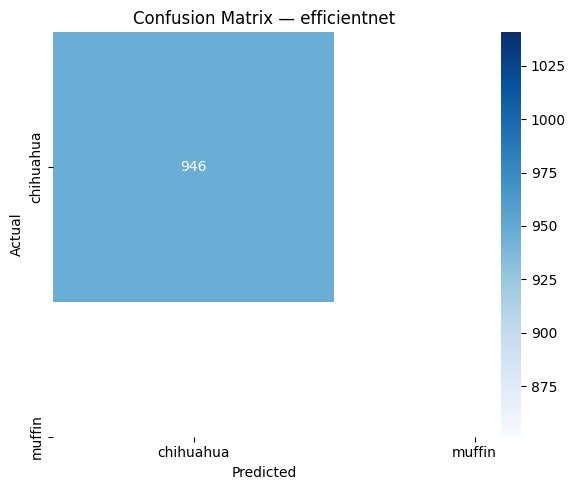

ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

In [16]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {MODEL_NAME}')
plt.tight_layout()
plt.show()

print(classification_report(true_labels, pred_labels, target_names=class_names))